In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
pip install albumentations opencv-python


In [3]:
import os
import glob
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms



In [4]:
def preprocess_green_clahe(image):
    green = image[:, :, 1]

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(green)

    # jadi 1 channel
    enhanced = np.expand_dims(enhanced, axis=-1)
    return enhanced

In [5]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(512, 512),   # 🔥 WAJIB
    A.HorizontalFlip(p=0.7),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.7),
    A.RandomBrightnessContrast(p=0.7),
    A.Normalize(mean=(0.5,), std=(0.5,)),  # untuk 1 channel
    ToTensorV2()
])

test_transform = A.Compose([
    A.Resize(512, 512),   # 🔥 WAJIB
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

In [6]:
import cv2
import numpy as np
from torch.utils.data import Dataset
from PIL import Image

class DRIVEDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # === LOAD IMAGE ===
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # === PREPROCESSING (BENAR DI SINI) ===
        image = preprocess_green_clahe(image)

        mask = Image.open(self.mask_paths[idx]).convert("L")
        mask = np.array(mask)

        # === BINARISASI MASK (WAJIB) ===
        mask = (mask > 0).astype(np.float32)

        # === AUGMENTATION ===
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask  = augmented['mask']

        # 🔥 TAMBAHKAN INI
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        return image, mask

In [7]:
# Direktori input dan output
img_dir = "/content/drive/MyDrive/Colab Notebooks/DRIVE/training/images"
mask_dir = "/content/drive/MyDrive/Colab Notebooks/DRIVE/training/1st_manual"


from glob import glob
import os

train_imgs = sorted(glob(os.path.join(img_dir, "*.tif")))
train_masks = sorted(glob(os.path.join(mask_dir, "*.gif")))

test_imgs = sorted(glob("/content/drive/MyDrive/Colab Notebooks/DRIVE/test/images/*.tif"))
test_masks = sorted(glob("/content/drive/MyDrive/Colab Notebooks/DRIVE/test/masks/*.gif"))

In [8]:
print("Train images:", len(train_imgs))
print("Train masks:", len(train_masks))
print("Test images:", len(test_imgs))
print("Test masks:", len(test_masks))

Train images: 20
Train masks: 20
Test images: 20
Test masks: 20


In [9]:
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader

kf = KFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(train_imgs)):

    train_fold_imgs = [train_imgs[i] for i in train_idx]
    train_fold_masks = [train_masks[i] for i in train_idx]

    val_fold_imgs = [train_imgs[i] for i in val_idx]
    val_fold_masks = [train_masks[i] for i in val_idx]

    train_dataset = DRIVEDataset(
        train_fold_imgs,
        train_fold_masks,
        transform=train_transform   # AUGMENTASI DI SINI
    )

    val_dataset = DRIVEDataset(
        val_fold_imgs,
        val_fold_masks,
        transform=test_transform    # TANPA AUGMENTASI
    )

    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=4)
    val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [10]:
test_dataset = DRIVEDataset(test_imgs, test_masks, transform=test_transform)
test_loader  = DataLoader(test_dataset, batch_size=4, shuffle=False)

In [11]:
print(len(train_fold_imgs), len(val_fold_imgs))

18 2


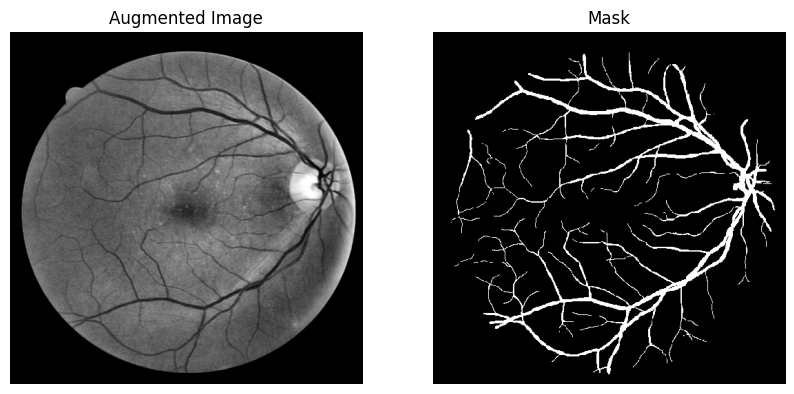

In [12]:
import matplotlib.pyplot as plt

# ambil 1 sample dari train_dataset (yang sudah diaugmentasi)
image, mask = train_dataset[0]

# ubah tensor → numpy
image = image.permute(1, 2, 0).cpu().numpy()
mask = mask.squeeze().cpu().numpy()

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray' if image.shape[2]==1 else None)
plt.title("Augmented Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask")
plt.axis('off')

plt.show()

In [13]:
# === HITUNG JUMLAH DATA TRAINING & VALIDATION ===
print("========================================")
# Define all_files by combining training and test image paths
all_files = train_imgs + test_imgs
print("Jumlah total data:", len(all_files))
print("Jumlah data training :", len(train_dataset))
print("Jumlah data validation :", len(val_dataset))
print("Jumlah data test :", len(test_dataset))
print("========================================")

Jumlah total data: 40
Jumlah data training : 18
Jumlah data validation : 2
Jumlah data test : 20


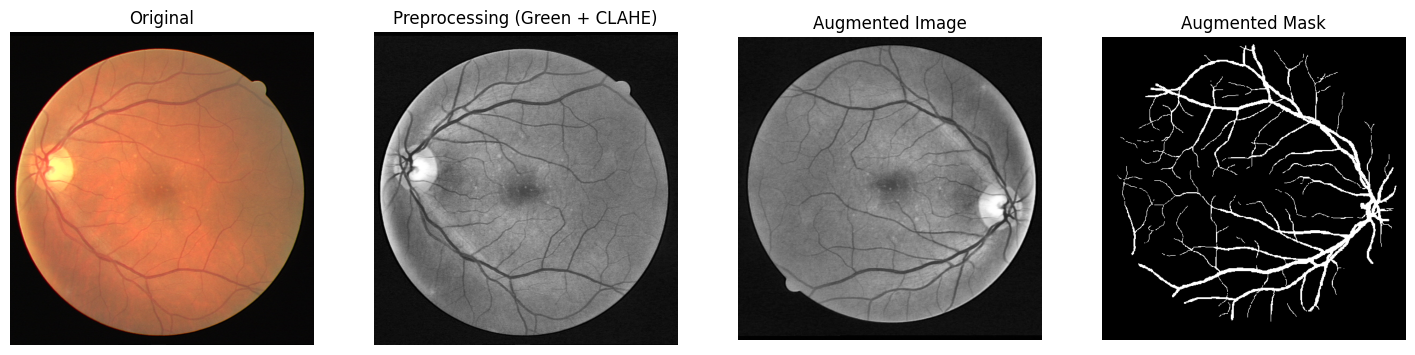

In [14]:
# === LOAD IMAGE ===
img = cv2.imread("/content/drive/MyDrive/Colab Notebooks/DRIVE/training/images/21_training.tif")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# === PREPROCESSING ===
preprocessed = preprocess_green_clahe(img)

if preprocessed.ndim == 2:
    preprocessed = preprocessed[..., None]

# === LOAD MASK ===
mask = cv2.imread("/content/drive/MyDrive/Colab Notebooks/DRIVE/training/1st_manual/21_manual1.gif", cv2.IMREAD_GRAYSCALE)
mask = (mask > 0).astype("float32")
mask = mask[..., None]

# === AUGMENTATION ===
augmented = train_transform(image=preprocessed, mask=mask)

aug_img = augmented["image"]
aug_mask = augmented["mask"]

# === CONVERT UNTUK VISUALISASI ===
aug_img_np = aug_img.permute(1, 2, 0).cpu().numpy()
aug_mask_np = aug_mask.squeeze().cpu().numpy()

# === PLOT ===
plt.figure(figsize=(18, 6))

plt.subplot(1, 4, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(preprocessed.squeeze(), cmap='gray')
plt.title("Preprocessing (Green + CLAHE)")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(aug_img_np.squeeze(), cmap='gray')
plt.title("Augmented Image")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(aug_mask_np, cmap='gray')
plt.title("Augmented Mask")
plt.axis("off")

plt.show()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


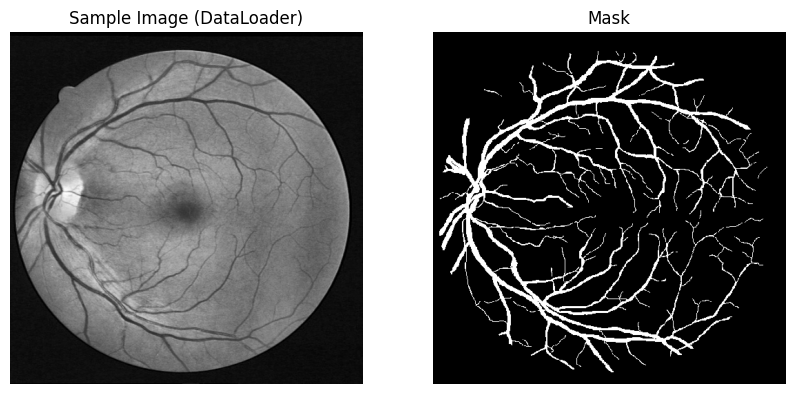

In [15]:
batch = next(iter(train_loader))
imgs, masks = batch

img = imgs[0]
mask = masks[0]

img_np = img.permute(1, 2, 0).cpu().numpy()
mask_np = mask.squeeze().cpu().numpy()

# undo normalize
mean = 0.5
std = 0.5
img_np = (img_np * std) + mean
img_np = np.clip(img_np, 0, 1)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
if img_np.shape[2] == 1:
    plt.imshow(img_np.squeeze(), cmap='gray')
else:
    plt.imshow(img_np)
plt.title("Sample Image (DataLoader)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask_np, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

In [16]:
image, mask = train_dataset[0]
print(image.shape)

torch.Size([1, 512, 512])


In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

# === DeepLabV3 Encoder: ResNet Backbone ===
class DeepLabEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(pretrained=True)
        resnet.conv1 = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        self.initial = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool
        )

        self.layer1 = resnet.layer1  # 256  # CHANGED (comment)
        self.layer2 = resnet.layer2  # 512  # CHANGED (comment)
        self.layer3 = resnet.layer3  # 1024 # CHANGED (comment)
        self.layer4 = resnet.layer4  # 2048 # CHANGED (comment)

    def forward(self, x):
        x0 = self.initial(x)
        x1 = self.layer1(x0)  # 256
        x2 = self.layer2(x1)  # 512
        x3 = self.layer3(x2)  # 1024
        x4 = self.layer4(x3)  # 2048
        return x1, x2, x3, x4


# === ASPP Module ===
class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.atrous1 = nn.Conv2d(in_channels, out_channels, 1, padding=0, dilation=1)
        self.atrous6 = nn.Conv2d(in_channels, out_channels, 3, padding=6, dilation=6)
        self.atrous12 = nn.Conv2d(in_channels, out_channels, 3, padding=12, dilation=12)
        self.atrous18 = nn.Conv2d(in_channels, out_channels, 3, padding=18, dilation=18)
        self.global_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1),
            nn.ReLU()
        )
        self.conv_out = nn.Conv2d(out_channels * 5, out_channels, 1)

    def forward(self, x):
        size = x.shape[2:]
        f1 = self.atrous1(x)
        f2 = self.atrous6(x)
        f3 = self.atrous12(x)
        f4 = self.atrous18(x)
        f5 = self.global_pool(x)
        f5 = F.interpolate(f5, size=size, mode='bilinear', align_corners=False)
        x = torch.cat([f1, f2, f3, f4, f5], dim=1)
        return self.conv_out(x)


class UNetDecoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Correct skip channels for ResNet50
        # bridge (ASPP) out_channels = 256
        # x4 = 2048, x3 = 1024, x2 = 512, x1 = 256
        self.up1 = self.block(256, 2048, 256)  # bridge + x4
        self.up2 = self.block(256, 1024, 128)  # up1 + x3
        self.up3 = self.block(128, 512, 64)    # up2 + x2
        self.up4 = self.block(64, 256, 32)     # up3 + x1

        self.final = nn.Conv2d(32, 1, 1)

    def block(self, in_channels, skip_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels + skip_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, skips):
        x1, x2, x3, x4 = skips

        # === UP 1 === (bridge + x4)
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        if x4.shape[2:] != x.shape[2:]:
            x4 = F.interpolate(x4, size=x.shape[2:], mode='bilinear', align_corners=False)
        x = self.up1(torch.cat([x, x4], dim=1))

        # === UP 2 === (up1 + x3)
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        if x3.shape[2:] != x.shape[2:]:
            x3 = F.interpolate(x3, size=x.shape[2:], mode='bilinear', align_corners=False)
        x = self.up2(torch.cat([x, x3], dim=1))

        # === UP 3 === (up2 + x2)
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        if x2.shape[2:] != x.shape[2:]:
            x2 = F.interpolate(x2, size=x.shape[2:], mode='bilinear', align_corners=False)
        x = self.up3(torch.cat([x, x2], dim=1))

        # === UP 4 === (up3 + x1)
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        if x1.shape[2:] != x.shape[2:]:
            x1 = F.interpolate(x1, size=x.shape[2:], mode='bilinear', align_corners=False)
        x = self.up4(torch.cat([x, x1], dim=1))

        x = F.interpolate(x, size=(512, 512), mode='bilinear', align_corners=False)

        return self.final(x)


# === Hybrid Model ===
class ResASPP_UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = DeepLabEncoder()
        self.aspp = ASPP(2048, 256)
        self.decoder = UNetDecoder()

    def forward(self, x):
        x1, x2, x3, x4 = self.encoder(x)
        bridge = self.aspp(x4)
        out = self.decoder(bridge, [x1, x2, x3, x4])  # CHANGED
        return out


In [18]:
import torch.nn as nn
import torch.nn.functional as F

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        intersection = (pred * target).sum(dim=(2,3))
        union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class BoundaryLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, pred, target):
        pred = torch.sigmoid(pred)

        sobel_x = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]],
                               dtype=torch.float32).to(pred.device).view(1,1,3,3)
        sobel_y = sobel_x.permute(0,1,3,2)

        pred_edge = F.conv2d(pred, sobel_x, padding=1) + F.conv2d(pred, sobel_y, padding=1)
        target_edge = F.conv2d(target, sobel_x, padding=1) + F.conv2d(target, sobel_y, padding=1)

        return F.l1_loss(pred_edge, target_edge)


class TopologyLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        return F.binary_cross_entropy(pred, target)


class HybridLoss(nn.Module):
    def __init__(self, w_dice=1.0, w_boundary=0.5, w_topo=0.3):
        super().__init__()
        self.dice = DiceLoss()
        self.boundary = BoundaryLoss()
        self.topo = TopologyLoss()

        self.w_dice = w_dice
        self.w_boundary = w_boundary
        self.w_topo = w_topo

    def forward(self, pred, target):
        return (
            self.w_dice * self.dice(pred, target) +
            self.w_boundary * self.boundary(pred, target) +
            self.w_topo * self.topo(pred, target)
        )

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time # Import the time module


def dice_score(preds, targets, threshold=0.5):
    preds = (preds > threshold).float()
    intersection = (preds * targets).sum()
    return (2. * intersection) / (preds.sum() + targets.sum() + 1e-8)

def accuracy_score(preds, targets, threshold=0.5):
    preds = (preds > threshold).float()
    correct = (preds == targets).float().sum()
    total = torch.numel(targets)
    return correct / total

def train_model(model, train_loader, val_loader, epochs=30, lr=1e-4, device='cuda'):
    model.to(device)
    criterion = HybridLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_dice": [],
        "val_dice": []
    }

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        running_acc = 0
        running_dice = 0

        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            running_acc  += accuracy_score(outputs, masks).item()
            running_dice += dice_score(outputs, masks).item()

        train_loss = running_loss / len(train_loader)
        train_acc  = running_acc  / len(train_loader)
        train_dice = running_dice / len(train_loader)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_dice'].append(train_dice)


        # ==========================
        # VALIDATION
        # ==========================
        model.eval()
        val_loss = 0
        total_dice = 0
        total_acc = 0

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)

                loss = criterion(outputs, masks)
                val_loss += loss.item()

                total_dice += dice_score(outputs, masks).item()
                total_acc  += accuracy_score(outputs, masks).item()

        val_loss /= len(val_loader)
        val_dice = total_dice / len(val_loader)
        val_acc  = total_acc  / len(val_loader)

        history['val_loss'].append(val_loss)
        history['val_dice'].append(val_dice)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | "
              f"Train Dice: {train_dice:.4f} | Val Dice: {val_dice:.4f}")


    end_time = time.time() # Record the end time
    total_training_time = end_time - start_time
    print(f"\nTotal Training Time: {total_training_time:.2f} seconds")

    return model, history


In [20]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(18, 5))


    # Plot Loss
    plt.subplot(1,3,1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1,3,2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Val Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Dice Score
    plt.subplot(1, 3, 3)
    plt.plot(history['train_dice'], label='Train Dice', color='blue')
    plt.plot(history['val_dice'], label='Val Dice', color='orange')
    plt.title('Dice Score per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Dice')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [21]:
def plot_history(history, title_suffix=""):
    plt.figure(figsize=(18, 5))

    # Loss
    plt.subplot(1,3,1)
    plt.plot(history['train_loss'], label='Train Loss')
    if 'val_loss' in history:
        plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f'Loss {title_suffix}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy
    plt.subplot(1,3,2)
    plt.plot(history['train_acc'], label='Train Acc')
    if 'val_acc' in history:
        plt.plot(history['val_acc'], label='Val Acc')
    plt.title(f'Accuracy {title_suffix}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Dice
    plt.subplot(1,3,3)
    plt.plot(history['train_dice'], label='Train Dice')
    if 'val_dice' in history:
        plt.plot(history['val_dice'], label='Val Dice')
    plt.title(f'Dice Score {title_suffix}')
    plt.xlabel('Epoch')
    plt.ylabel('Dice')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [22]:
pip install torchinfo


In [23]:
def evaluate_test(model, loader, device):
    model.eval()

    total_loss = 0
    # total_dice = 0 # These are not explicitly used in the return, removed for clarity
    # total_acc  = 0 # These are not explicitly used in the return, removed for clarity

    criterion = HybridLoss()


    TP, TN, FP, FN = 0, 0, 0, 0
    dice_total, iou_total, n = 0, 0, 0

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)

            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            loss = criterion(outputs, masks) # Calculate loss
            total_loss += loss.item() # Accumulate loss

            TP += ((preds == 1) & (masks == 1)).sum().item()
            TN += ((preds == 0) & (masks == 0)).sum().item()
            FP += ((preds == 1) & (masks == 0)).sum().item()
            FN += ((preds == 0) & (masks == 1)).sum().item()

            intersection = (preds * masks).sum(dim=(2,3))
            union = preds.sum(dim=(2,3)) + masks.sum(dim=(2,3))

            dice = (2 * intersection + 1e-6) / (union + 1e-6)
            iou = (intersection + 1e-6) / (union - intersection + 1e-6)

            dice_total += dice.mean().item()
            iou_total += iou.mean().item()
            n += 1

    return {
        "loss": total_loss / n, # Added loss to the return dictionary
        "Accuracy": (TP + TN) / (TP + TN + FP + FN + 1e-6),
        "Sensitivity": TP / (TP + FN + 1e-6),
        "Specificity": TN / (TN + FP + 1e-6),
        "Dice": dice_total / n,
        "IoU": iou_total / n
    }

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

fold_results = []

import os

# Folder penyimpanan
save_dir = "/content/drive/MyDrive/Colab Notebooks/DRIVE/"
os.makedirs(save_dir, exist_ok=True)

for fold, (train_idx, val_idx) in enumerate(kf.split(train_imgs)):
    print(f"\n===== FOLD {fold+1} ====")

    train_fold_imgs = [train_imgs[i] for i in train_idx]
    train_fold_masks = [train_masks[i] for i in train_idx]

    val_fold_imgs = [train_imgs[i] for i in val_idx]
    val_fold_masks = [train_masks[i] for i in val_idx]

    # Dataset
    train_dataset = DRIVEDataset(train_fold_imgs, train_fold_masks, transform=train_transform)
    val_dataset   = DRIVEDataset(val_fold_imgs, val_fold_masks, transform=test_transform)

    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=4)
    val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=4)

    model = ResASPP_UNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = HybridLoss()

    num_epochs = 100

    # 🔥 HISTORY (INI YANG PENTING)
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_dice": [],
        "val_dice": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0
        running_dice = 0
        running_acc  = 0

        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)

            outputs = model(images)
            preds = torch.sigmoid(outputs)

            loss = criterion(outputs, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            running_dice += dice_score(preds, masks).item()
            running_acc  += accuracy_score(preds, masks).item()

        # === TRAIN METRICS ===
        train_loss = running_loss / len(train_loader)
        train_dice = running_dice / len(train_loader)
        train_acc  = running_acc  / len(train_loader)

        # === VALIDATION ===
        val_metrics = evaluate_test(model, val_loader, device)

        # === SIMPAN HISTORY ===
        history["train_loss"].append(train_loss)
        history["train_dice"].append(train_dice)
        history["train_acc"].append(train_acc)

        history["val_loss"].append(val_metrics["loss"])
        history["val_dice"].append(val_metrics["Dice"])
        history["val_acc"].append(val_metrics["Accuracy"])

        # === PRINT (SEPERTI train_model) ===
        print(f"Fold {fold+1} | Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_metrics['loss']:.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_metrics['Accuracy']:.4f} | "
              f"Train Dice: {train_dice:.4f} | Val Dice: {val_metrics['Dice']:.4f}")


===== FOLD 1 ====


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Fold 1 | Epoch 1/100 | Train Loss: 1.2254 | Val Loss: 1.2146 | Train Acc: 0.9133 | Val Acc: 0.9194 | Train Dice: 0.0000 | Val Dice: 0.0000
Fold 1 | Epoch 2/100 | Train Loss: 1.1989 | Val Loss: 1.1608 | Train Acc: 0.9110 | Val Acc: 0.9194 | Train Dice: 0.0000 | Val Dice: 0.0000
Fold 1 | Epoch 3/100 | Train Loss: 1.1291 | Val Loss: 1.3412 | Train Acc: 0.9114 | Val Acc: 0.9194 | Train Dice: 0.0000 | Val Dice: 0.0000
Fold 1 | Epoch 4/100 | Train Loss: 1.0891 | Val Loss: 1.2336 | Train Acc: 0.9130 | Val Acc: 0.9194 | Train Dice: 0.0000 | Val Dice: 0.0000
Fold 1 | Epoch 5/100 | Train Loss: 1.0722 | Val Loss: 1.2929 | Train Acc: 0.9114 | Val Acc: 0.9194 | Train Dice: 0.0000 | Val Dice: 0.0000
Fold 1 | Epoch 6/100 | Train Loss: 1.0519 | Val Loss: 1.2367 | Train Acc: 0.9145 | Val Acc: 0.9194 | Train Dice: 0.0000 | Val Dice: 0.0000
Fold 1 | Epoch 7/100 | Train Loss: 1.0424 | Val Loss: 1.0962 | Train Acc: 0.9132 | Val Acc: 0.9194 | Train Dice: 0.0000 | Val Dice: 0.0000
Fold 1 | Epoch 8/100 | Trai

In [25]:
# === FINAL EVALUATION ===
final_metrics = evaluate_test(model, val_loader, device)


fold_results.append({
    "metrics": final_metrics,
    "history": history
})

In [26]:
save_path_bobot = os.path.join(
    save_dir,
    f"DRIVE_model_bobot_resASPP_Unet_paper_aug_fold{fold+1}.pth"
)

torch.save({
    'model_state_dict': model.state_dict(),
    'metrics': final_metrics,
    'history': history
}, save_path_bobot)

print(f"✅ Model + history fold {fold+1} disimpan di:")
print(save_path_bobot)

✅ Model + history fold 10 disimpan di:
/content/drive/MyDrive/Colab Notebooks/DRIVE/DRIVE_model_bobot_resASPP_Unet_paper_aug_fold10.pth


In [27]:
model = ResASPP_UNet()
path = "/content/drive/MyDrive/Colab Notebooks/DRIVE/DRIVE_model_bobot_resASPP_Unet_paper_aug_fold5.pth"
checkpoint = torch.load(path, map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])

model.to(device)
model.eval()

# optional
print(checkpoint['metrics'])

{'loss': 0.5295774936676025, 'Accuracy': 0.9542646408071954, 'Sensitivity': 0.7186159074443192, 'Specificity': 0.9756903732161558, 'Dice': 0.7230736017227173, 'IoU': 0.566353440284729}


In [28]:
def plot_history(history):
    plt.figure(figsize=(18, 5))

    # === LOSS ===
    plt.subplot(1,3,1)
    plt.plot(history.get('train_loss', []), label='Train Loss', marker='o')
    plt.plot(history.get('val_loss', []), label='Val Loss', marker='o')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # === ACCURACY ===
    plt.subplot(1,3,2)
    plt.plot(history.get('train_acc', []), label='Train Accuracy', marker='o')
    plt.plot(history.get('val_acc', []), label='Val Accuracy', marker='o')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # === DICE ===
    plt.subplot(1,3,3)
    plt.plot(history.get('train_dice', []), label='Train Dice', marker='o')
    plt.plot(history.get('val_dice', []), label='Val Dice', marker='o')
    plt.title('Dice Score per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Dice')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [29]:


# === Tampilkan model summary ===
from torchinfo import summary # Import summary
print("Model Summary:")
summary(
    model,
    input_size=(1, 1, 512, 512),  # (batch, channels, H, W) - Adjusted for single channel green image and common size for DRIVE
    col_names=["input_size", "output_size", "num_params", "kernel_size", "mult_adds"],
    col_width=20,
    row_settings=["var_names"]
)

Model Summary:


Layer (type (var_name))                       Input Shape          Output Shape         Param #              Kernel Shape         Mult-Adds
ResASPP_UNet (ResASPP_UNet)                   [1, 1, 512, 512]     [1, 1, 512, 512]     --                   --                   --
├─DeepLabEncoder (encoder)                    [1, 1, 512, 512]     [1, 256, 128, 128]   --                   --                   --
│    └─Sequential (initial)                   [1, 1, 512, 512]     [1, 64, 128, 128]    --                   --                   --
│    │    └─Conv2d (0)                        [1, 1, 512, 512]     [1, 64, 256, 256]    3,136                [7, 7]               205,520,896
│    │    └─BatchNorm2d (1)                   [1, 64, 256, 256]    [1, 64, 256, 256]    128                  --                   128
│    │    └─ReLU (2)                          [1, 64, 256, 256]    [1, 64, 256, 256]    --                   --                   --
│    │    └─MaxPool2d (3)                     [1, 64

In [30]:
save_path = '/content/drive/MyDrive/Colab Notebooks/DRIVE/DRIVE_model_ab_resASPP_Unet_paper_aug.pth'
torch.save(model, save_path)

print(f"Model disimpan di: {save_path}")


Model disimpan di: /content/drive/MyDrive/Colab Notebooks/DRIVE/DRIVE_model_ab_resASPP_Unet_paper_aug.pth


In [31]:
save_path_bobot = "/content/drive/MyDrive/Colab Notebooks/DRIVE/DRIVE_model_bobot_resASPP_Unet_paper_aug.pth"
torch.save(model.state_dict(), save_path_bobot)
print("Saved to:", save_path_bobot)


Saved to: /content/drive/MyDrive/Colab Notebooks/DRIVE/DRIVE_model_bobot_resASPP_Unet_paper_aug.pth


In [32]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Pastikan cell definisi class ResASPP_UNet sudah dijalankan sebelumnya
with torch.serialization.safe_globals([ResASPP_UNet]):
    model = torch.load("/content/drive/MyDrive/Colab Notebooks/DRIVE/DRIVE_model_ab_resASPP_Unet_paper_aug.pth",
                       map_location=device, weights_only=False)

model.eval()
print("✅ Model berhasil dimuat tanpa file .py terpisah.")


✅ Model berhasil dimuat tanpa file .py terpisah.


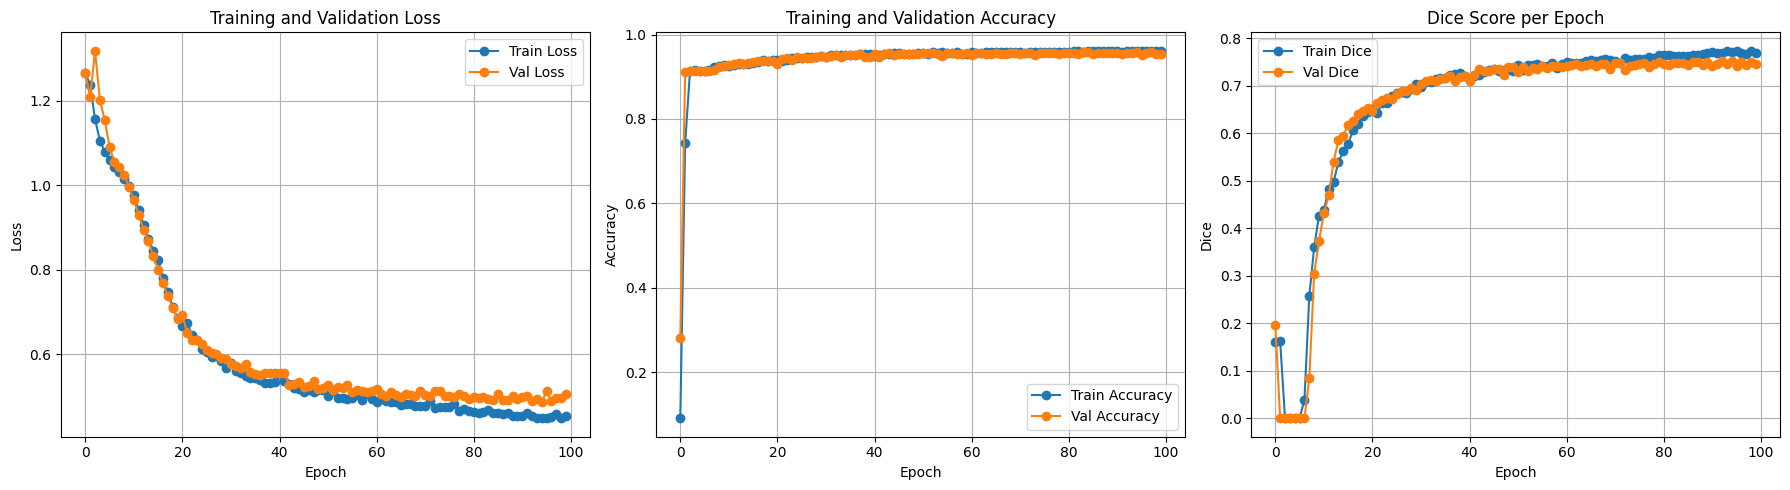

In [33]:
# Make sure the cell defining plot_history is run before this cell.
plot_history(history)

In [34]:
#Visualisasi Prediksi
def visualize_prediction(model, dataset, index=0, device='cuda'): # Add device as an argument with default 'cuda'
    model.eval()
    image, true_mask = dataset[index]
    image_input = image.unsqueeze(0).to(device)

    with torch.no_grad():
        pred_mask = model(image_input)
        pred_mask = (pred_mask.squeeze().cpu().numpy() > 0.5).astype(float)

    image_np = image.permute(1, 2, 0).numpy()
    true_mask_np = true_mask.squeeze().numpy()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image_np)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(true_mask_np, cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap='gray')
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

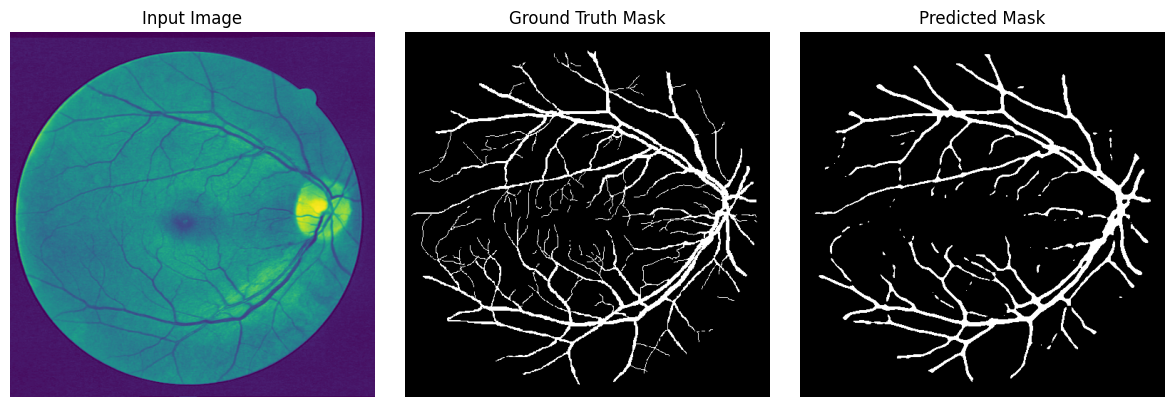

In [35]:
visualize_prediction(model, val_dataset, index=0)


In [36]:
print(len(test_dataset.image_paths))
print(len(test_dataset.mask_paths))

20
20


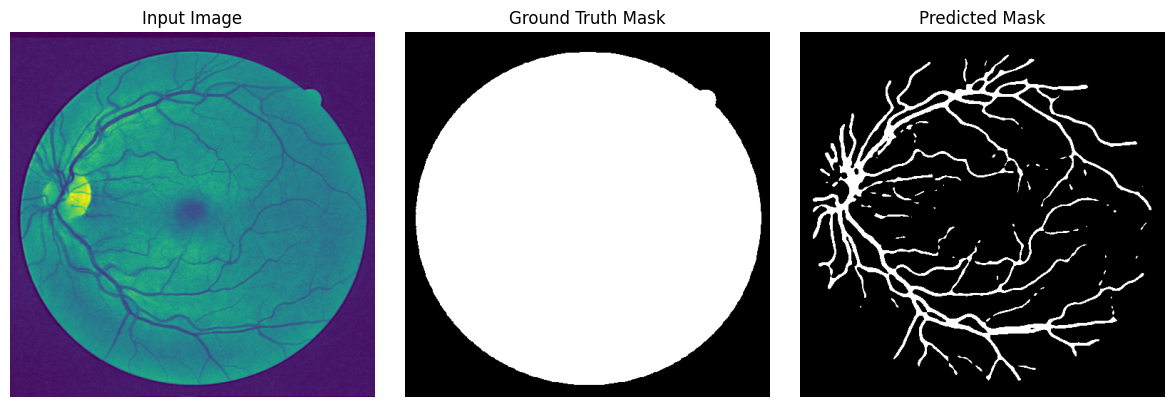

In [37]:

visualize_prediction(model, test_dataset, index=0)


In [41]:
import numpy as np

# Process fold_results to get a consistent list of metric dictionaries for averaging
processed_metrics = []
for fold_res in fold_results:
    if isinstance(fold_res, dict) and "metrics" in fold_res and isinstance(fold_res["metrics"], dict):
        processed_metrics.append(fold_res["metrics"])
    elif isinstance(fold_res, dict) and "loss" in fold_res: # Assuming 'loss' is a key present in direct metric dicts
        processed_metrics.append(fold_res)


print("\n=== CROSS VALIDATION RESULT ===")
if not processed_metrics:
    print("No valid metric dictionaries found in fold_results to average.")
else:
    # Use the keys from the first processed metric dictionary for averaging
    # This assumes all metric dictionaries have the same set of keys
    avg_results = {
        k: np.mean([res[k] for res in processed_metrics])
        for k in processed_metrics[0]
    }

    for k, v in avg_results.items():
        print(f"{k}: {v:.4f}")


=== CROSS VALIDATION RESULT ===
loss: 0.5196
Accuracy: 0.9526
Sensitivity: 0.7590
Specificity: 0.9711
Dice: 0.7363
IoU: 0.5829
